# **Student Clustering Analysis: An Unsupervised Machine Learning Approach**

In [67]:
# import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import my_utils as mu

# import machine learning libraries
import sklearn as sk
import tensorflow as tf


# import configuration settings
from sklearn import set_config
from imblearn.over_sampling import SMOTE

set_config(transform_output="pandas")



# EDA - Exploratory Data Analysis

In [68]:
# load the dataset
df = pd.read_csv("Option_B_clustering.csv")

# display the first few rows of the dataset
df.head(5)

,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,passed_course,assess_score_1,assess_score_2,assess_score_3,assess_score_4,assess_score_5
0,1,2,9,2,0,240,0,1,78,85,80,85,82
1,0,2,2,1,0,60,0,1,70,68,70,64,60
2,0,3,5,1,0,60,0,1,72,71,74,88,75
3,0,1,5,0,0,60,0,1,69,30,63,35,75
4,1,2,3,0,0,60,0,1,70,65,62,75,68


In [69]:
# check out the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12737 entries, 0 to 12736
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   gender                12737 non-null  int64
 1   highest_education     12737 non-null  int64
 2   imd_band              12737 non-null  int64
 3   age_band              12737 non-null  int64
 4   num_of_prev_attempts  12737 non-null  int64
 5   studied_credits       12737 non-null  int64
 6   disability            12737 non-null  int64
 7   passed_course         12737 non-null  int64
 8   assess_score_1        12737 non-null  int64
 9   assess_score_2        12737 non-null  int64
 10  assess_score_3        12737 non-null  int64
 11  assess_score_4        12737 non-null  int64
 12  assess_score_5        12737 non-null  int64
dtypes: int64(13)
memory usage: 1.3 MB


In [70]:
# check for missing values
df.isnull().sum()

gender                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
passed_course           0
assess_score_1          0
assess_score_2          0
assess_score_3          0
assess_score_4          0
assess_score_5          0
dtype: int64

In [71]:
# chek for duplicates
print(f'Number of duplicates: {df.duplicated().sum()}')

# drop duplicates
df = df.drop_duplicates()
print(f'Number of duplicates after dropping: {df.duplicated().sum()}')


Number of duplicates: 7
Number of duplicates after dropping: 0


In [72]:
# explore [gender] feature
mu.profile_column(df, 'gender')

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,2 — Low
Skewness,0.213965
,count
gender,
0,7042
1,5688


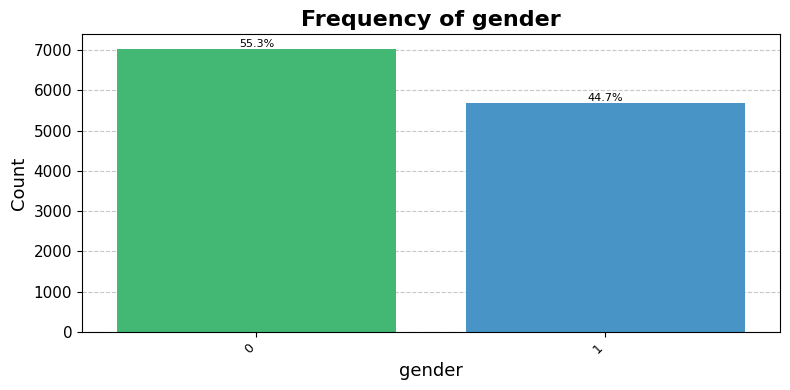

In [73]:
# plot [gender] feature
mu.plot_univariate_analysis(df, 'gender', dtype='categorical')

---

In [74]:
# Explore [age] feature
mu.profile_column(df, 'highest_education')

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,5 — Low
Skewness,-0.189069
,count
highest_education,
3,5916
1,4737


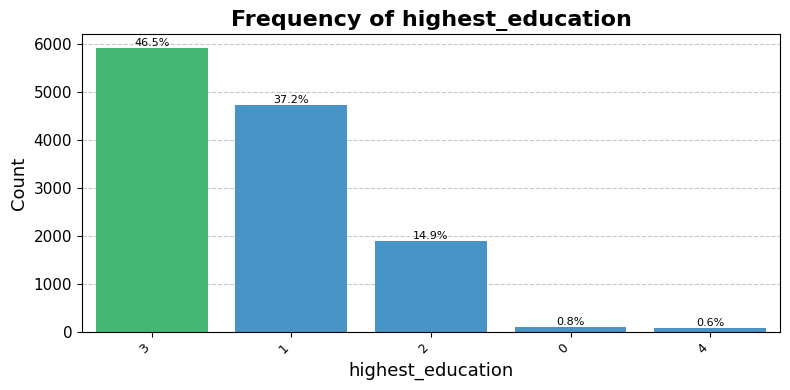

In [75]:
# plot [highest_education] feature
mu.plot_univariate_analysis(df, 'highest_education', dtype='categorical')

---

In [76]:
# Explore [imd_band] feature
mu.profile_column(df, 'imd_band')

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,10 — Low
Skewness,0.057805
,count
imd_band,
3,1486
2,1338


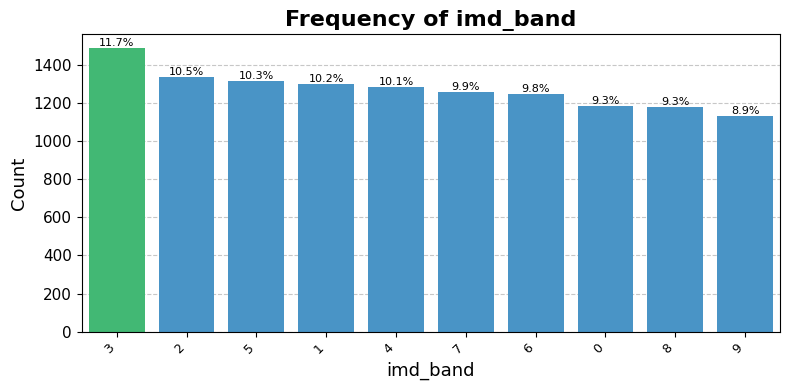

In [77]:
# plot [imd_band] feature
mu.plot_univariate_analysis(df, 'imd_band', dtype='categorical')

---

In [78]:
# Explore [age_band] feature
mu.profile_column(df, 'age_band')

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,3 — Low
Skewness,0.869909
,count
age_band,
0,8507
1,4128


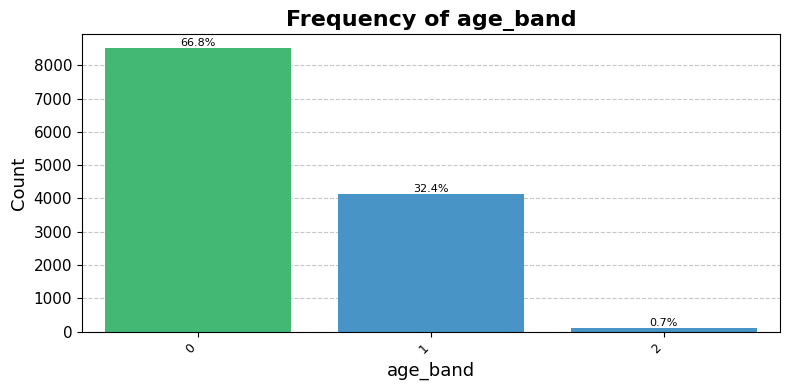

In [79]:
# plot [age_band] feature
mu.plot_univariate_analysis(df, 'age_band', dtype='categorical')

---

In [80]:
# Explore num_of_prev_attempts feature
mu.profile_column(df, 'num_of_prev_attempts')

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,7 — Low
Skewness,4.720019
,count
num_of_prev_attempts,
0,11634
1,886


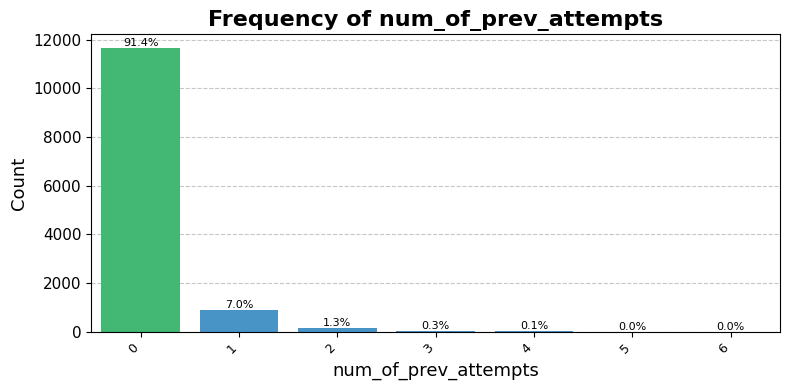

In [81]:
# Plot num_of_prev_attempts feature
mu.plot_univariate_analysis(df, 'num_of_prev_attempts', dtype='categorical')

---

In [82]:
# Explore studied_credits feature
mu.profile_column(df, 'studied_credits', show_value_counts = False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,40 — Medium
Skewness,1.802529


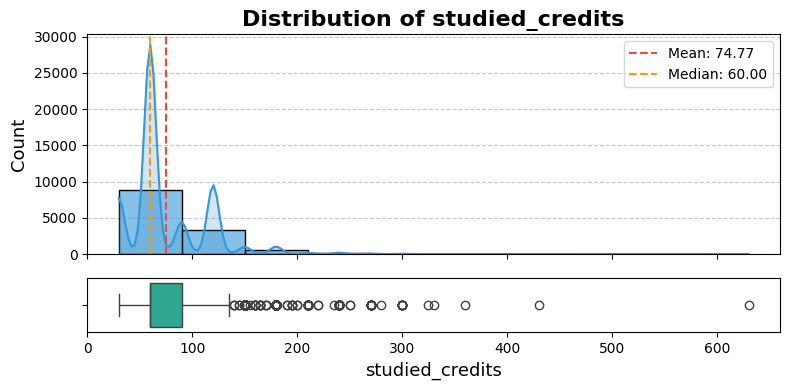

In [83]:
# Plot studied_credits feature
mu.plot_univariate_analysis(df, 'studied_credits', bins = 10)

---

In [84]:
# Explore disability feature
mu.profile_column(df, 'disability')

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,2 — Low
Skewness,2.825497
,count
disability,
0,11560
1,1170


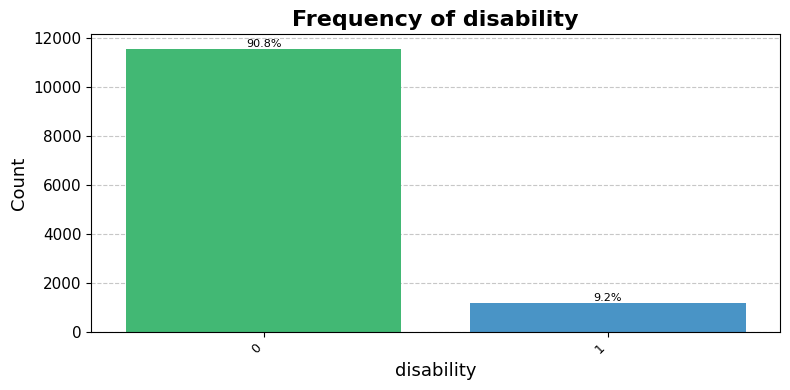

In [85]:
# Plot disability feature
mu.plot_univariate_analysis(df, 'disability', dtype='categorical')

---

In [86]:
# Explore passed_course feature
mu.profile_column(df, 'passed_course')

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,2 — Low
Skewness,-1.237093
,count
passed_course,
1,9713
0,3017


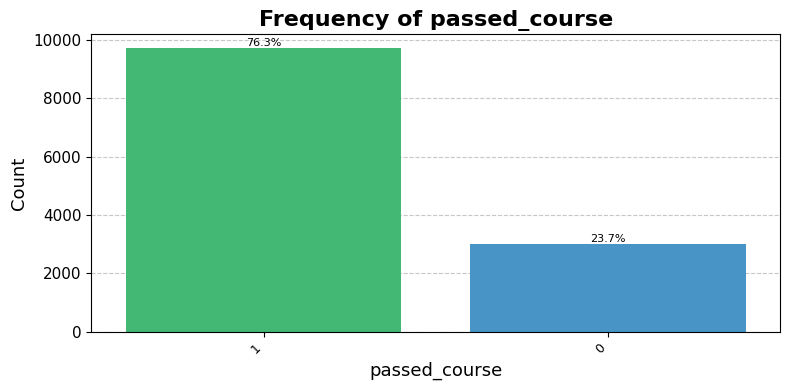

In [87]:
# Plot passed_course feature
mu.plot_univariate_analysis(df, 'passed_course', dtype='categorical')

---

In [88]:
# Explore assess_score_1 feature
mu.profile_column(df, 'assess_score_1', show_value_counts = False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,86 — High
Skewness,-1.585484


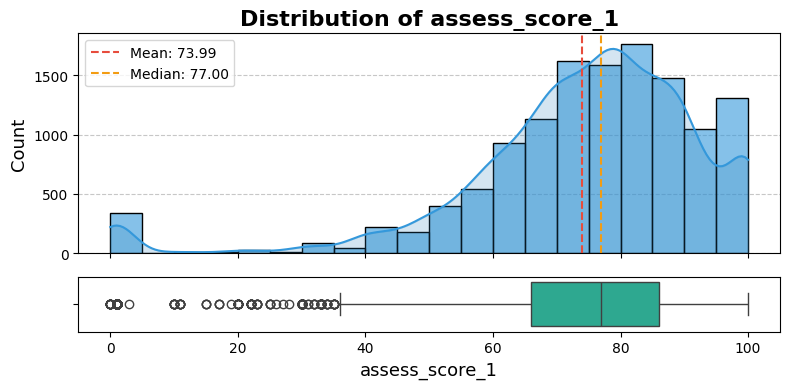

In [89]:
# Plot assess_score_1 feature
mu.plot_univariate_analysis(df, 'assess_score_1')

---

In [90]:
# Explore assess_score_2 feature
mu.profile_column(df, 'assess_score_2', show_value_counts = False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,92 — High
Skewness,-0.7812


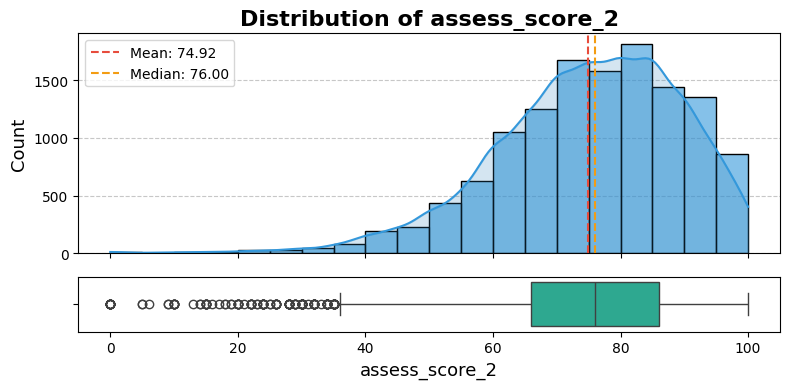

In [91]:
# Plot assess_score_2 feature
mu.plot_univariate_analysis(df, 'assess_score_2')

---

In [92]:
# Explore assess_score_3 feature
mu.profile_column(df, 'assess_score_3', show_value_counts = False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,98 — High
Skewness,-0.900716


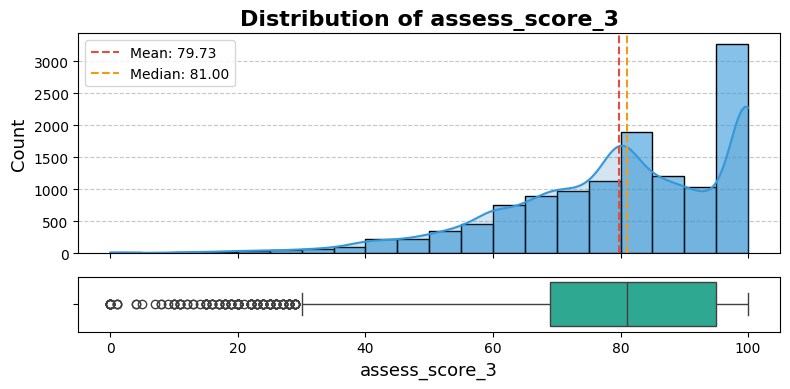

In [93]:
# Plot assess_score_3 feature
mu.plot_univariate_analysis(df, 'assess_score_3')

---

In [94]:
# Explore assess_score_4 feature
mu.profile_column(df, 'assess_score_4', show_value_counts = False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,98 — High
Skewness,-0.814457


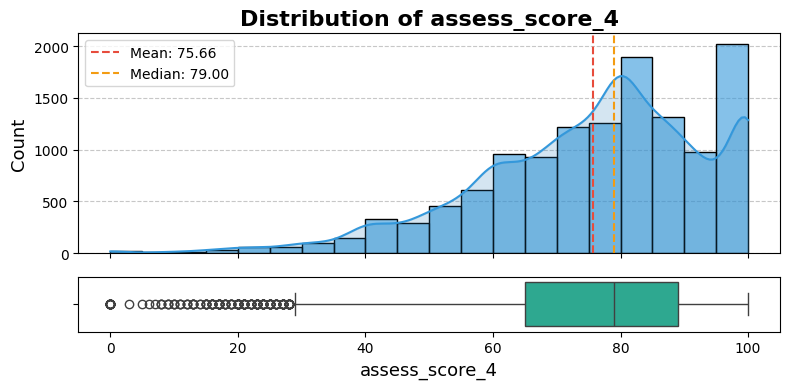

In [95]:
# Plot assess_score_4 feature
mu.plot_univariate_analysis(df, 'assess_score_4')

---

In [96]:
# Explore assess_score_5 feature
mu.profile_column(df, 'assess_score_5', show_value_counts = False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,98 — High
Skewness,-0.962983


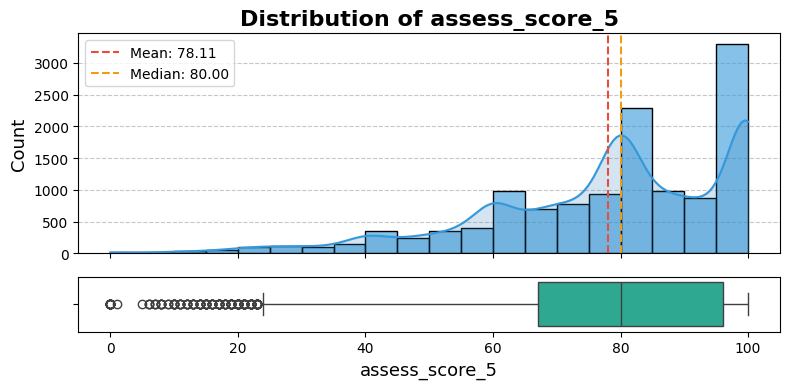

In [97]:
# Plot assess_score_5 feature
mu.plot_univariate_analysis(df, 'assess_score_5')

---

# Run K-Means clustering algorithm

In [98]:
# initialize the scaler object for the numerical features
scaler = sk.preprocessing.StandardScaler()

# fit and transform the numerical features
df_scaled = scaler.fit_transform(df)

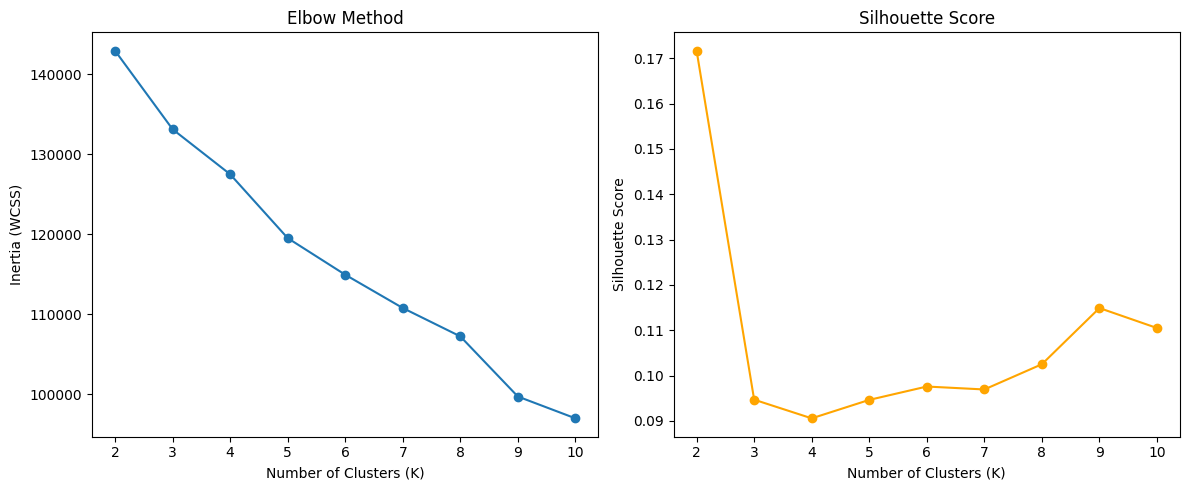

In [99]:
# find the optimal number of clusters using the elbow method
mu.plot_optimal_k(df_scaled)

## Cluster Selection Justification

The **silhouette score** and **elbow plot** both pointed to **k=2** as the optimal number of clusters.

> Students naturally fall into two groups: those who **passed** and those who **failed**.

---

In [100]:
# initialize the KMeans model with the optimal number of clusters
kmeans = sk.cluster.KMeans(n_clusters=2, random_state=42)

kmeans.fit(df_scaled)

df['cluster'] = kmeans.labels_

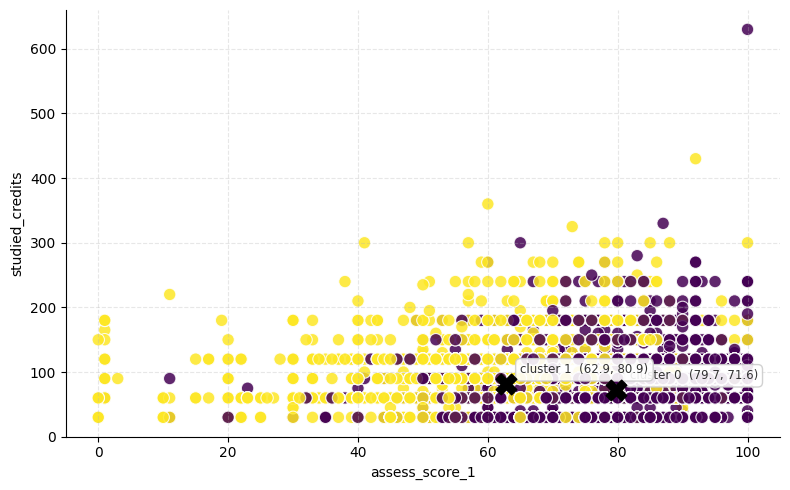

In [101]:
# show the 2 clusters in a simple scatter plot
mu.plot_clusters(df, 'assess_score_1', 'studied_credits', kmeans = kmeans, scaler = scaler, color = 'viridis')

## 🔵 Scatter Plot Analysis — Cluster Separation

> The two clusters show a degree of **overlap**, reflected by a silhouette score
> of **~0.17**. This is attributed to the **natural complexity of human behavioral
> data**, though higher separation is achievable in other datasets.

---

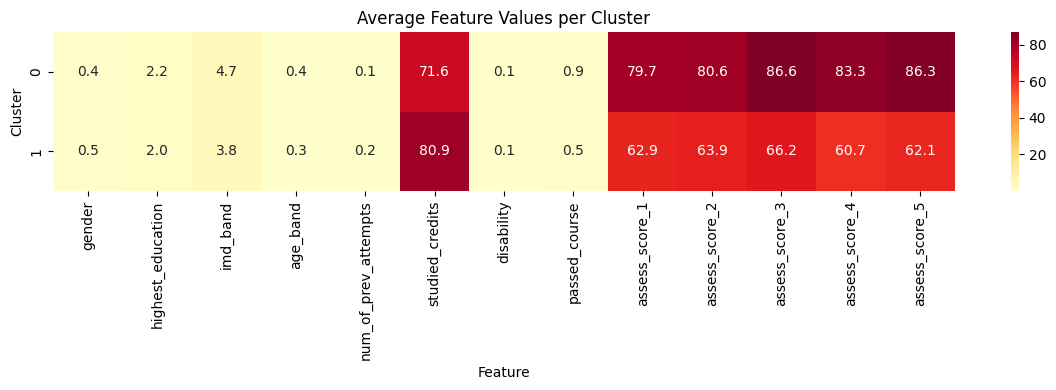

In [102]:
# Heatmap of average feature values per cluster
cluster_means = df.groupby('cluster').mean()

plt.figure(figsize=(12, 4))
sns.heatmap(cluster_means, annot=True, fmt='.1f', cmap='YlOrRd')

plt.title('Average Feature Values per Cluster')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

## 🔥 Heatmap Analysis — Average Feature Values per Cluster

### 📊 Overall Finding

**Cluster 0** consistently achieved **higher assessment scores** across all five assessments
compared to **Cluster 1**.

### 🔍 Key Distinction — Studied Credits

| | Studied Credits | Assessment Scores |
|---|---|---|
| **Cluster 0** | 🟢 Lower | 🟢 Higher |
| **Cluster 1** | 🔴 Higher | 🔴 Lower |

### 💡 Interpretation

> Cluster 0 students carried a **lower credit load**, allowing them to dedicate more
> time and focus to each course — reflected in their **stronger academic performance**.

> Cluster 1 students were enrolled in a **significantly higher number of credits**,
> resulting in a heavier workload. This overload likely **divided their attention**
> across multiple courses, ultimately leading to **lower assessment scores**.

---

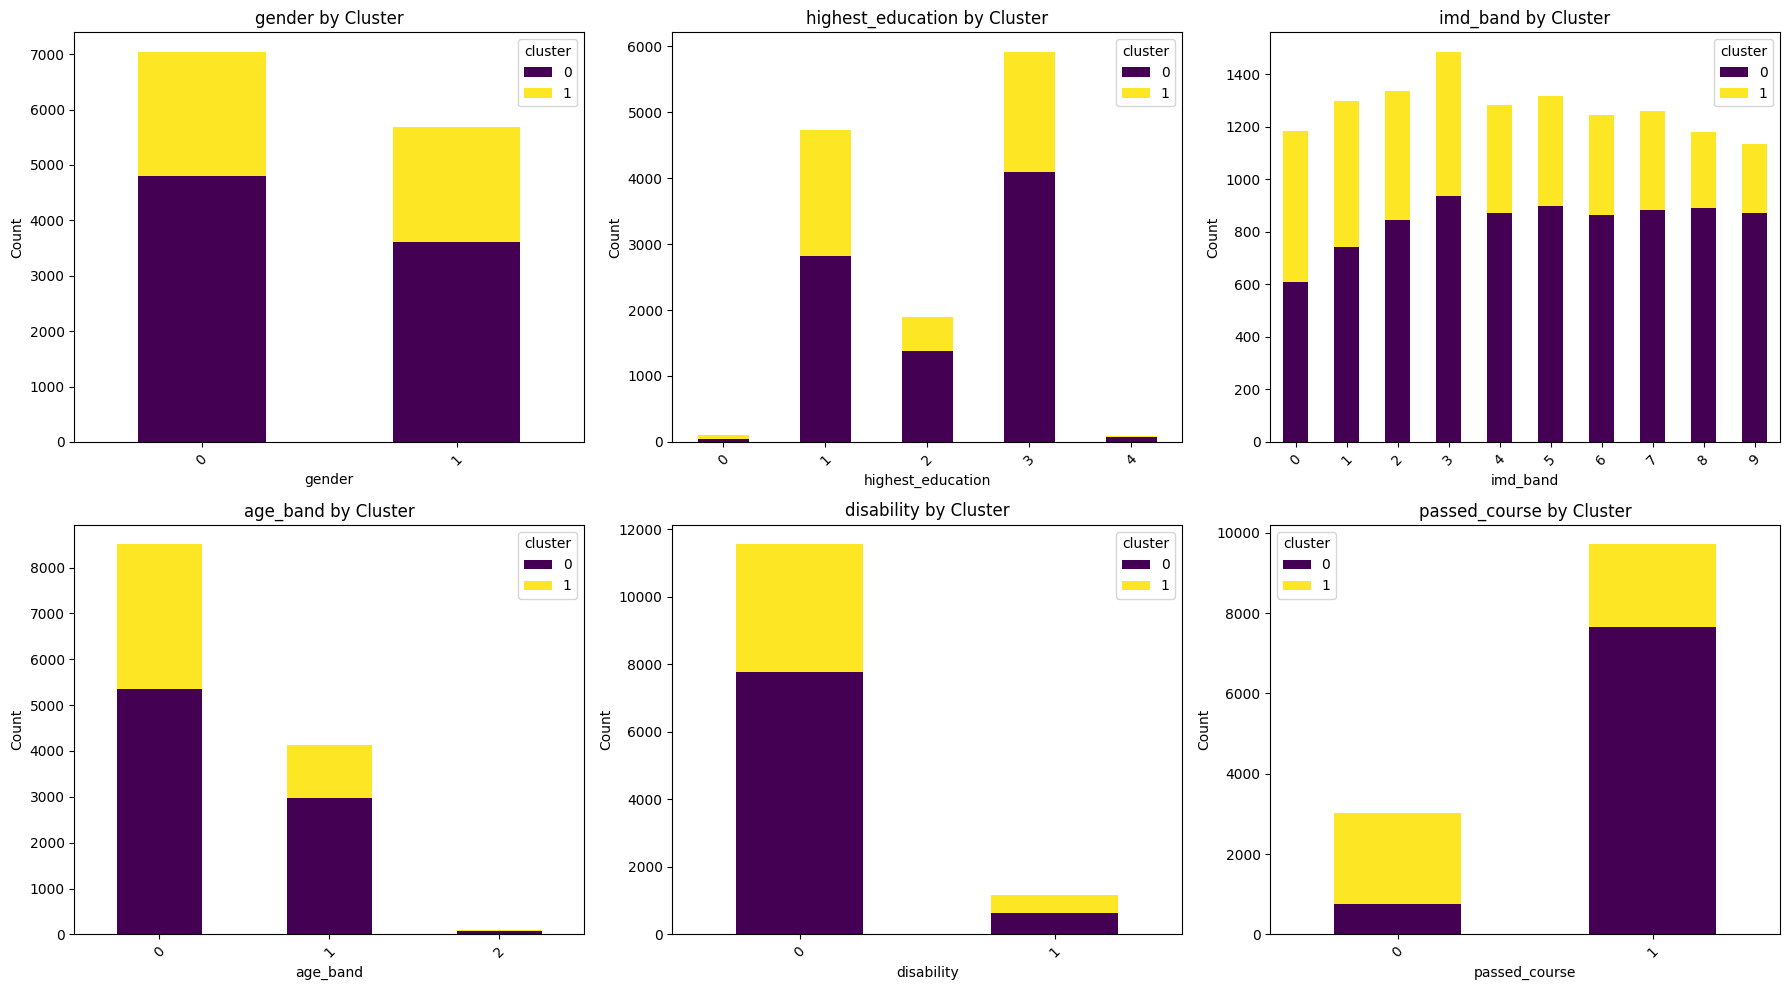

In [103]:
# categorical features to analyze for cluster distribution
categorical_cols = ['gender', 'highest_education', 'imd_band', 
                    'age_band', 'disability', 'passed_course']

# Categorical — Stacked Bar Chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    df.groupby([col, 'cluster']).size().unstack().plot(
        kind='bar', stacked=True, ax=axes[i], 
        colormap='viridis', legend=True
    )
    axes[i].set_title(f'{col} by Cluster')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



## 📊 Stacked Bar Chart Analysis — Categorical Features by Cluster

### ⚠️ Note on Category Labels

> Due to the absence of a data dictionary, all category labels are represented as
> **numeric codes**, which limits the depth of interpretation. However, general trends
> can still be observed across all features.

---

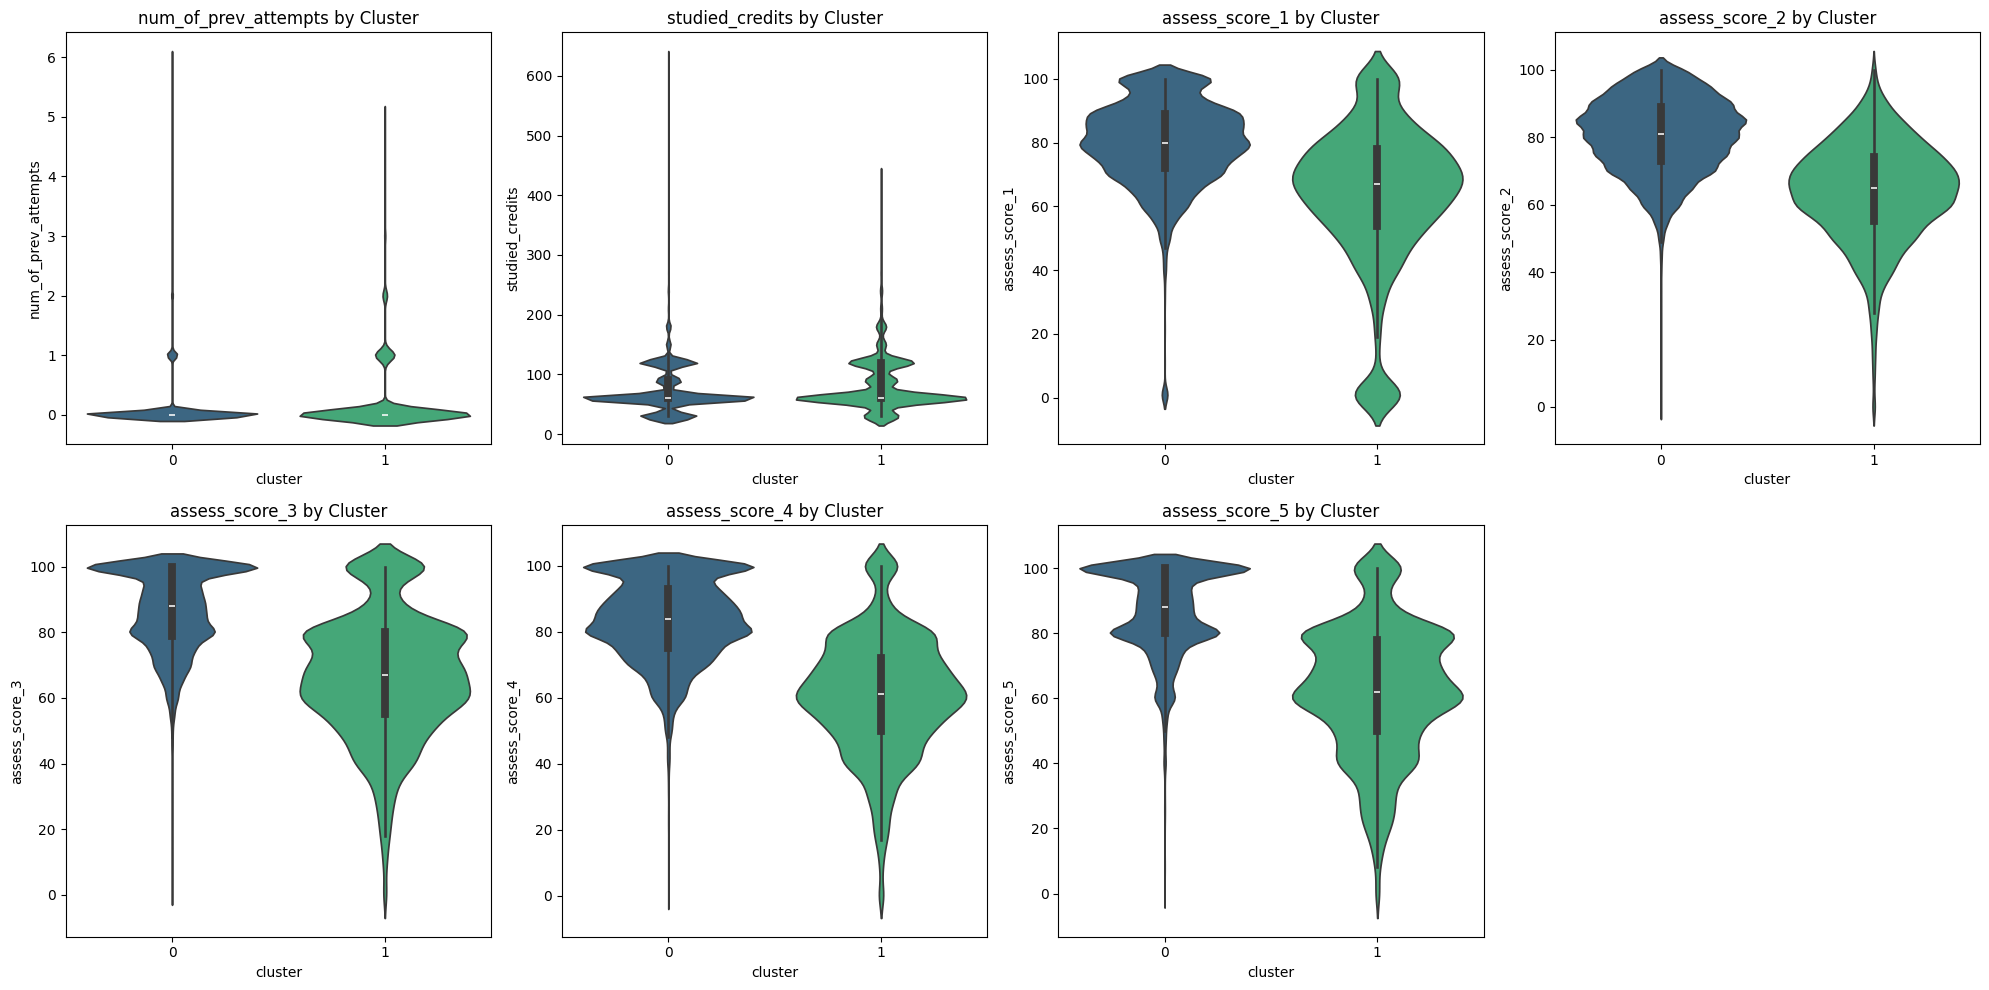

In [104]:
# numerical features to analyze for cluster distribution
numerical_cols = ['num_of_prev_attempts', 'studied_credits', 'assess_score_1', 
                  'assess_score_2', 'assess_score_3', 'assess_score_4', 'assess_score_5']


# Numerical — Box Plot
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.violinplot(data=df, x='cluster', y=col, ax=axes[i],
                hue='cluster', palette='viridis', legend=False)
    axes[i].set_title(f'{col} by Cluster')

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 🎻 Violin Plot Analysis — Numerical Features by Cluster

### 📌 Key Finding

Across all numerical features, **Cluster 0 consistently shows higher average values**
compared to Cluster 1.

### 🔍 Interpretation

**🔹 Cluster 0 — Focused & Consistent**
Cluster 0 students demonstrate a **tight distribution around the mean**, indicating
consistent performance across all assessments. Their lower credit load allowed them
to maintain focus, which is clearly reflected in their stable and higher scores.

**🔹 Cluster 1 — Overloaded & Inconsistent**
Cluster 1 students show a **wider distribution with higher variation**, suggesting
inconsistent performance. This can be attributed to their heavier course load, which
divided their attention across multiple subjects — ultimately leading to mental fatigue
and a noticeable decline in academic performance.

> 💡 This is a classic **quality vs. quantity** trade-off — focusing on fewer
> courses leads to better and more consistent outcomes.

---

# **Student Modeling Analysis: A Supervised Machine Learning Approach**

In [105]:
# load the dataset for the modeling phase
df = pd.read_csv("Option_B_modeling.csv")

# run the an initial check on the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12737 entries, 0 to 12736
Columns: 931 entries, gender to presentation_2014J
dtypes: float64(910), int64(21)
memory usage: 90.5 MB


In [106]:
# check for duplicates and null values 
print(f'Number of duplicates: {df.duplicated().sum()}')
print(f'Number of null values:{df.isnull().sum().sum()}')

Number of duplicates: 0
Number of null values:0


In [107]:
# set the target variable 
y = df['passed_course']

# set the features for modeling
X = df.drop(columns=['passed_course'])

# train test and split the dataset
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, random_state=42)

In [108]:
# check the target variable distribution in the training set
y_train.value_counts(normalize=True)

passed_course
1    0.764552
0    0.235448
Name: proportion, dtype: float64

In [109]:
# scaling the features for modeling
scaler = sk.preprocessing.StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# initiate PCA for the modeling 
pca = sk.decomposition.PCA(n_components=0.9, random_state=42)

# fit and transform the training set and transform the test set
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# review the first few rows of the PCA-transformed training set
X_train_pca.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca331,pca332,pca333,pca334,pca335,pca336,pca337,pca338,pca339,pca340
2928,7.443536,-0.633356,0.570351,-1.214154,-1.643449,-0.507865,-0.511232,-0.586729,-0.628306,-0.050455,...,0.532619,0.072368,0.044770,0.316950,0.094725,-0.218759,-0.266622,0.100267,0.072528,0.210974
1746,1.480331,2.084526,-0.742251,0.600796,-0.973335,0.211729,0.015547,-1.738839,-0.412691,-0.745077,...,-0.714140,-0.030095,0.588964,1.084934,-0.600754,0.105395,-0.064160,0.844020,-0.349728,0.227665
10296,-9.614997,-1.889326,4.723620,-6.813660,0.619114,3.221340,2.541553,1.021411,-1.304200,0.592529,...,-0.756556,-0.814026,0.143450,0.241355,-0.333294,-1.074397,1.044266,-0.552916,0.031615,-0.563417
2873,9.092086,-0.293602,-0.864803,-0.428612,-1.168954,-0.088299,0.824379,0.964743,-0.163729,0.469494,...,-0.362362,0.328084,-0.027498,0.052067,-0.045139,-0.065157,-0.342547,0.036102,-0.025031,0.201840
6500,-12.284468,-6.116298,-3.281913,8.510684,-0.716206,-5.409999,-7.592807,-2.109600,-2.353755,-4.799915,...,-0.704054,0.111107,-0.148706,0.362380,1.512146,-0.399622,0.420970,-1.454614,0.664763,-0.443961


In [111]:
# run the components for the PCA 
pca.explained_variance_ratio_.sum()

np.float64(0.9001533509591206)

## **`Model 1`** — Baseline Model (No Regularization)

In [112]:
# initate the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_pca.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [113]:
model_1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │        21,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,001 (93.75 KB)

 Trainable params: 24,001 (93.75 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# compile the model
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]);

In [115]:
model_1.fit(X_train_pca, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8029 - loss: 0.4545 - precision_4: 0.8356 - recall_4: 0.9242 - val_accuracy: 0.8477 - val_loss: 0.3864 - val_precision_4: 0.8737 - val_recall_4: 0.9355
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8795 - loss: 0.2954 - precision_4: 0.8988 - recall_4: 0.9494 - val_accuracy: 0.8477 - val_loss: 0.3746 - val_precision_4: 0.8771 - val_recall_4: 0.9307
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9039 - loss: 0.2403 - precision_4: 0.9157 - recall_4: 0.9631 - val_accuracy: 0.8514 - val_loss: 0.3777 - val_precision_4: 0.8918 - val_recall_4: 0.9163
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9254 - loss: 0.1990 - precision_4: 0.9345 - recall_4: 0.9706 - val_accuracy: 0.8566 - val_loss: 0.3946 - val_precision_4: 0.8909 - val_recall_4: 0.9252
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9393 - loss: 0.1632 - precision_4: 0.9466 - recall_4: 0.9757 -

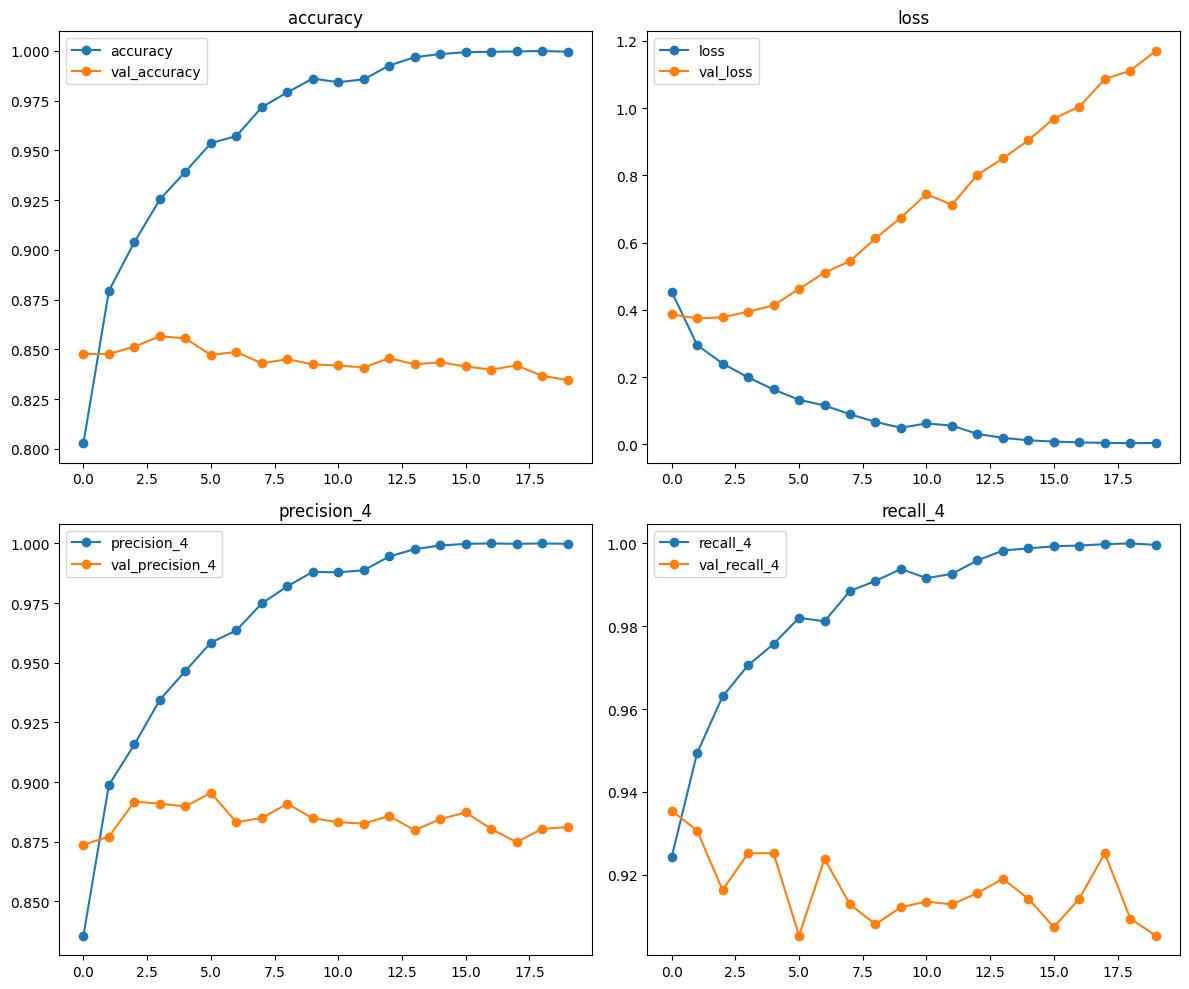

In [116]:
mu.plot_history(model_1.history);

## Model 1 — Baseline Model Analysis

The plots clearly indicate a **textbook overfitting** scenario. The model performs 
exceptionally well on the training data, reaching nearly **100% accuracy**, while 
the validation performance remains stuck around **84%**. This gap is consistent 
across all metrics — loss, accuracy, precision, and recall.

Most notably, the **training loss drops close to zero** while the **validation loss 
keeps climbing**, which is the clearest sign of overfitting.

### Why Dropout?
To address this, **Dropout layers** will be introduced in Model 2. Dropout works by 
randomly "switching off" a percentage of neurons during each training step, which 
prevents the model from memorizing the training data and forces it to learn more 
generalizable patterns.

---

## **`Model 2`**  — Deep Learning Model with Dropout Regularization

In [117]:
# run model 2
model_2 = tf.keras.Sequential([tf.keras.layers.Input(shape=(X_train_pca.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(1, activation='sigmoid')])

# run the summary for model 2
model_2.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │        21,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,001 (93.75 KB)

 Trainable params: 24,001 (93.75 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
# compile model 2
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]);

In [119]:
# fit the model 2
model_2.fit(X_train_pca, y_train, epochs=50, batch_size=32, validation_split=0.2);

Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7752 - loss: 0.5387 - precision_5: 0.8214 - recall_5: 0.9023 - val_accuracy: 0.8383 - val_loss: 0.3962 - val_precision_5: 0.8679 - val_recall_5: 0.9293
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8486 - loss: 0.3781 - precision_5: 0.8760 - recall_5: 0.9343 - val_accuracy: 0.8540 - val_loss: 0.3708 - val_precision_5: 0.8714 - val_recall_5: 0.9485
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8634 - loss: 0.3331 - precision_5: 0.8868 - recall_5: 0.9417 - val_accuracy: 0.8519 - val_loss: 0.3686 - val_precision_5: 0.8763 - val_recall_5: 0.9382
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8789 - loss: 0.3006 - precision_5: 0.8987 - recall_5: 0.9487 - val_accuracy: 0.8540 - val_loss: 0.3685 - val_precision_5: 0.8795 - val_recall_5: 0.9369
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8865 - loss: 0.2808 - precision_5: 0.9036 - recall_5: 0.9535 -

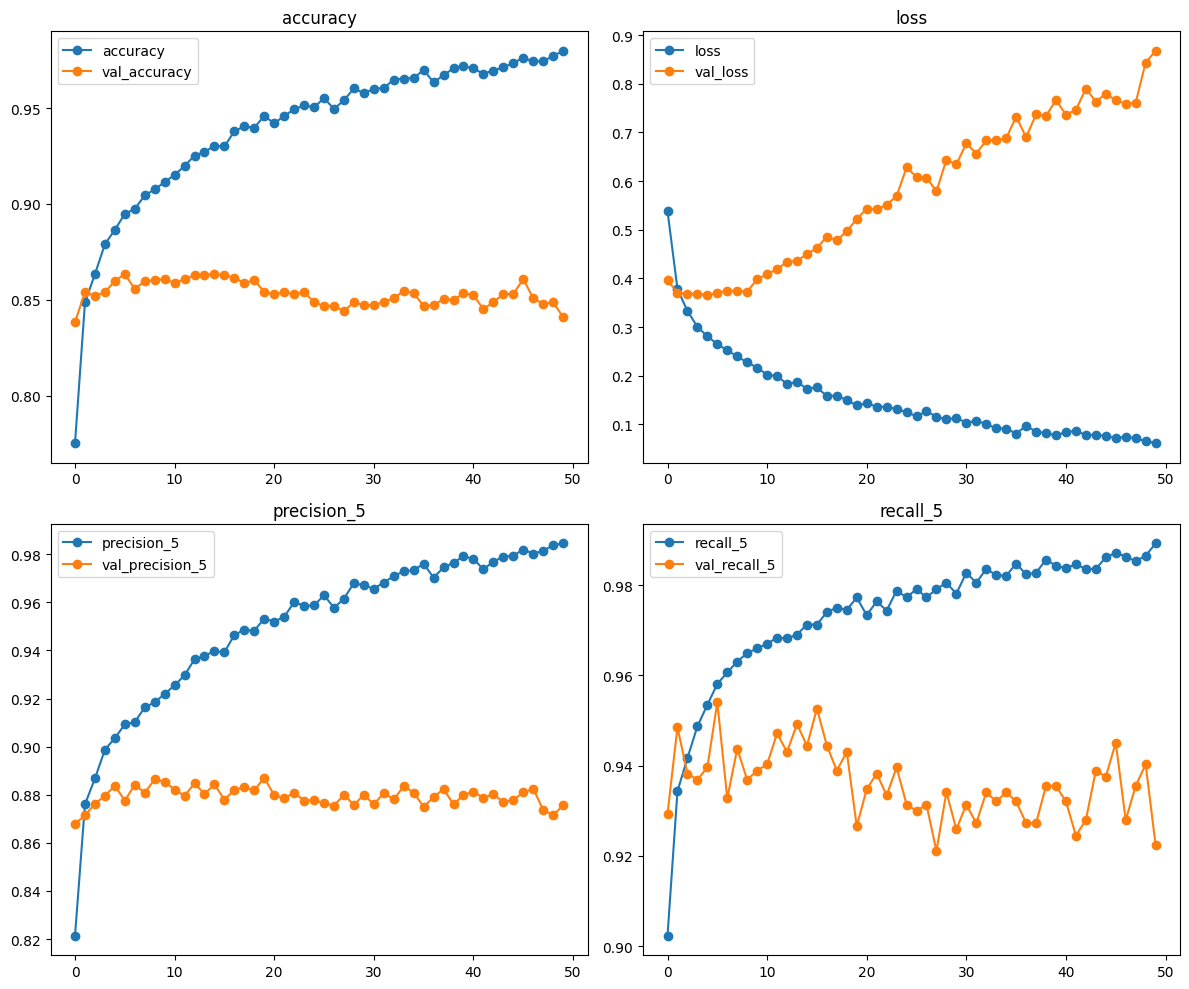

In [120]:
mu.plot_history(model_2.history);

## Model 2 — Deep Learning Model with Dropout Regularization

### What Changed?
Compared to Model 1, two **Dropout layers** were introduced — one after each hidden 
layer. The first Dropout layer was set to a rate of **0.3** (after the 64-neuron layer), 
and the second to **0.2** (after the 32-neuron layer). This tapering approach applies 
stronger regularization where there are more neurons, and gentler regularization 
where the layer is smaller.

### What Did the Plots Show?
The model still exhibits **overfitting**, but to a lesser degree than Model 1:

- **Training accuracy** dropped from **100%** to around **95%** — a sign that 
Dropout is working by preventing the model from fully memorizing the training data.
- **Validation accuracy** remained around **86%**, similar to Model 1.
- **Validation loss** still trends upward, indicating the model is still overfitting, 
but less aggressively than before.

### Why Add Dropout?
Dropout forces the model to learn more **generalizable patterns** by randomly 
switching off neurons during training. However, the improvement was slight, which 
suggests that Dropout alone is not sufficient — leading to the introduction of 
**EarlyStopping** in Model 3.

---

## **`Model 3`** — Dropout Regularization with Early Stopping

In [121]:
# Early Stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [122]:
# Model 3 - same as Model 2 + EarlyStopping
model_3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_pca.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [123]:
# compile model 3
model_3.compile(optimizer='adam', loss='binary_crossentropy', 
                metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

In [124]:
# fit the model 3
history_3 = model_3.fit(X_train_pca, y_train, 
                         epochs=50, 
                         batch_size=32, 
                         validation_split=0.2,
                         callbacks=[early_stopping])

Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7822 - loss: 0.5224 - precision_6: 0.8184 - recall_6: 0.9194 - val_accuracy: 0.8367 - val_loss: 0.4085 - val_precision_6: 0.8489 - val_recall_6: 0.9561
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8458 - loss: 0.3733 - precision_6: 0.8742 - recall_6: 0.9328 - val_accuracy: 0.8498 - val_loss: 0.3771 - val_precision_6: 0.8661 - val_recall_6: 0.9499
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8662 - loss: 0.3337 - precision_6: 0.8884 - recall_6: 0.9437 - val_accuracy: 0.8550 - val_loss: 0.3707 - val_precision_6: 0.8748 - val_recall_6: 0.9451
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8751 - loss: 0.3014 - precision_6: 0.8968 - recall_6: 0.9456 - val_accuracy: 0.8603 - val_loss: 0.3647 - val_precision_6: 0.8775 - val_recall_6: 0.9492
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8876 - loss: 0.2775 - precision_6: 0.9028 - recall_6: 0.9560 -

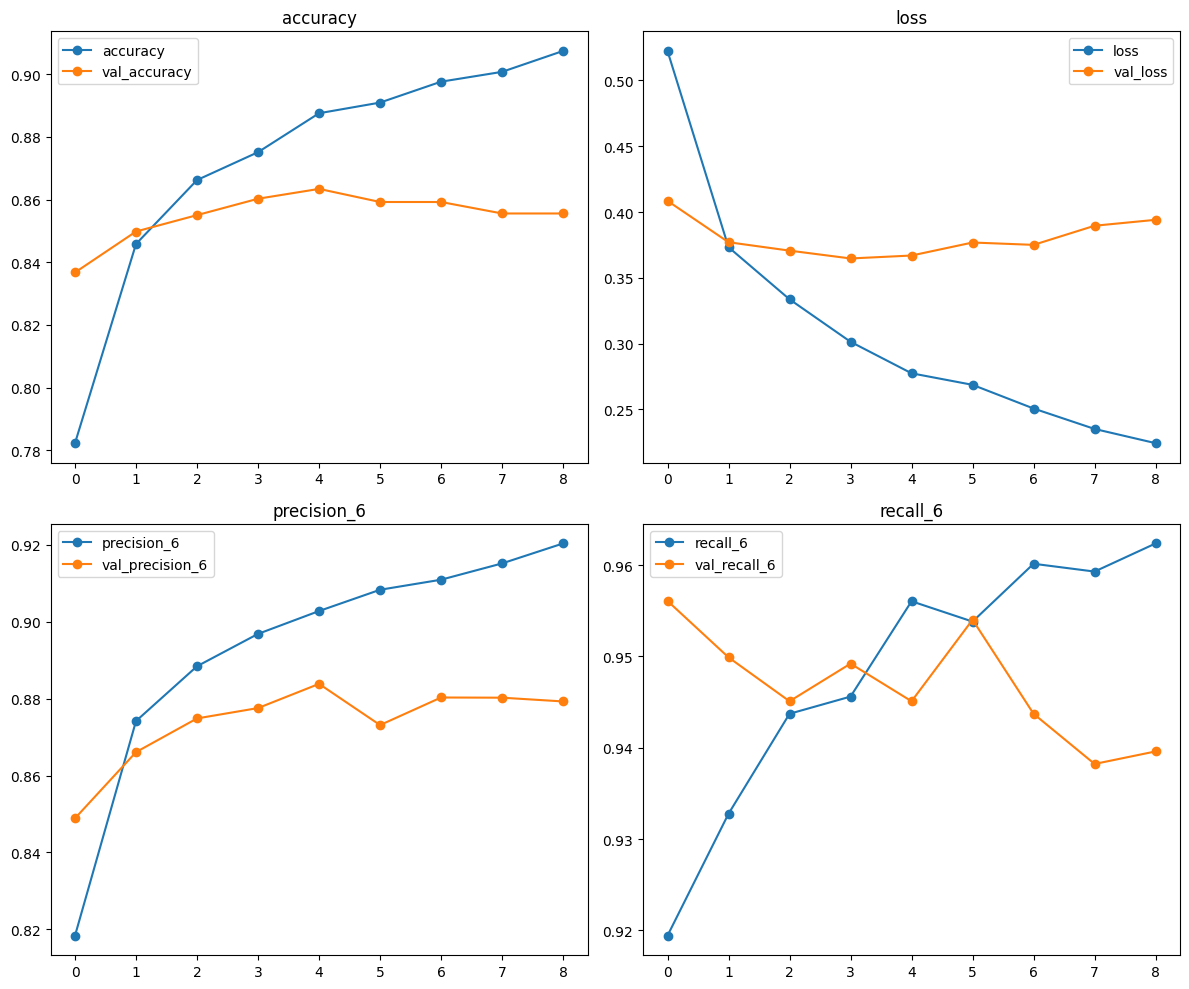

In [125]:
# plot the history of model 3
mu.plot_history(history_3);

## Model 3 — Dropout Regularization with Early Stopping

### What Changed?
Building on Model 2, **EarlyStopping** was added as a callback to monitor the 
validation loss during training. EarlyStopping was configured with a patience of 
**5 epochs** and `restore_best_weights=True`, meaning the model automatically 
rolls back to its best performing state before overfitting kicks in.

### What Did the Plots Show?
Model 3 showed a clear improvement over the previous two models:

- The model stopped training after only **8 epochs** instead of running the full 
50 — a sign that EarlyStopping successfully detected when further training 
was no longer beneficial.
- The **gap between training and validation curves** is significantly smaller 
compared to Model 1 and Model 2, indicating reduced overfitting.
- **Validation loss** stabilized around **0.38–0.41** instead of continuously 
climbing as seen in Model 1.
- **Validation accuracy** remained consistent at around **86%**, with less 
instability than previous models.

### Why Model 3 is the Final Model?
Model 3 strikes the best balance between **performance and efficiency**:

- It is the least overfitted of the three models.
- It stops training automatically when further epochs would waste computational 
resources without improving results.
- The combination of **Dropout regularization** and **EarlyStopping** proved 
more effective than either technique alone.

In [126]:
# Evaluate the final model on the test data
loss, accuracy, precision, recall = model_3.evaluate(X_test_pca, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8631 - loss: 0.3566 - precision_6: 0.8799 - recall_6: 0.9491
Test Loss: 0.3566
Test Accuracy: 0.8631
Test Precision: 0.8799
Test Recall: 0.9491


---

## **`Model 3`** — Dropout Regularization with Early Stopping Plus **SMOTE**

In [127]:
# Split validation set before applying SMOTE
X_train_s, X_val, y_train_s, y_val = sk.model_selection.train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42)

# Apply SMOTE only on training portion
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train_s)

In [128]:
# Check the new distribution
print(pd.Series(y_train_smote).value_counts(normalize=True))

passed_course
1    0.5
0    0.5
Name: proportion, dtype: float64


In [129]:
# Early Stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7615 - loss: 0.5167 - precision_7: 0.7694 - recall_7: 0.7469 - val_accuracy: 0.8210 - val_loss: 0.4242 - val_precision_7: 0.9135 - val_recall_7: 0.8459
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8425 - loss: 0.3587 - precision_7: 0.8422 - recall_7: 0.8429 - val_accuracy: 0.8325 - val_loss: 0.4113 - val_precision_7: 0.9167 - val_recall_7: 0.8589
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8706 - loss: 0.3066 - precision_7: 0.8683 - recall_7: 0.8737 - val_accuracy: 0.8362 - val_loss: 0.3914 - val_precision_7: 0.9082 - val_recall_7: 0.8740
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8831 - loss: 0.2732 - precision_7: 0.8806 - recall_7: 0.8864 - val_accuracy: 0.8388 - val_loss: 0.3977 - val_precision_7: 0.9079 - val_recall_7: 0.8781
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8977 - loss: 0.2459 - precision_7: 0.8985 - recall_7: 0.8966 -

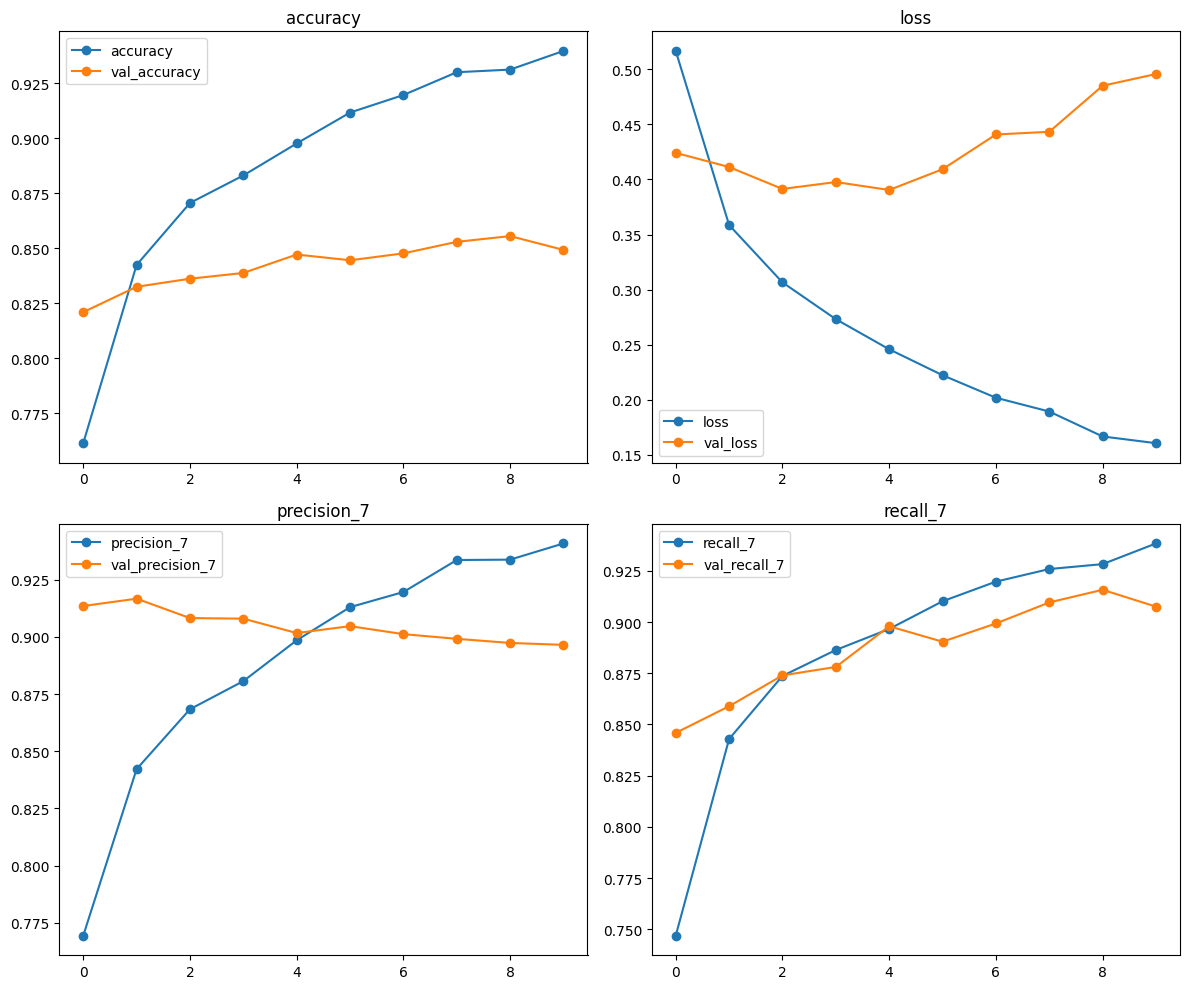

In [130]:
# Model 3 - Dropout + EarlyStopping + SMOTE
model_3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_smote.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

history_3 = model_3.fit(X_train_smote, y_train_smote,
                         epochs=50,
                         batch_size=32,
                         validation_data=(X_val, y_val),
                         callbacks=[early_stopping])

mu.plot_history(history_3);

In [131]:
# Evaluate on test data
loss, accuracy, precision, recall = model_3.evaluate(X_test_pca, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8509 - loss: 0.4101 - precision_7: 0.9026 - recall_7: 0.9007
Test Loss: 0.4101
Test Accuracy: 0.8509
Test Precision: 0.9026
Test Recall: 0.9007


---

## **Business Problem — Can This Model Help?**

The goal of this model is to predict whether a student will pass or fail, enabling 
educational institutions to identify at-risk students **before** it is too late to 
intervene.

Model 3, our final model, achieves a **test accuracy of 85.87%**, meaning it 
correctly predicts student outcomes 86 out of every 100 cases. Most importantly, 
the model demonstrates a strong **recall of 93.67%**, which is the most critical 
metric in this context. Recall measures how well the model catches students who 
are **actually at risk of failing** — a missed prediction means a struggling 
student receives no intervention, which is far more costly than falsely flagging 
a student who would have passed.

### How Would This Be Applied?
When a new student's academic data becomes available, it can be fed into the model 
to generate a **pass/fail prediction**. If the model flags a student as likely to 
fail, the institution can intervene early — through additional tutoring, counseling, 
or parental involvement — potentially changing the student's outcome entirely.

### Conclusion
While the model is not perfect, an **85.87% accuracy rate** combined with a 
**93.67% recall** makes it a valuable and reliable tool for early intervention, 
allowing schools to be proactive rather than reactive in supporting their students.